# Quickstart

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/etna-team/etna/master?filepath=examples/quickstart.ipynb)

In this introduction we will show how to make a simple forecast using ETNA library.

In [1]:
!pip install etna -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.2/565.2 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.4/139.4 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 7.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently tak

In [ ]:
import warnings

warnings.filterwarnings("ignore")

Let's load and prepare the data.

In [17]:
import pandas as pd

from etna.datasets import TSDataset

# Read the data
!wget https://raw.githubusercontent.com/tinkoff-ai/etna/refs/heads/master/examples/data/example_dataset.csv
df = pd.read_csv("/content/example_dataset.csv")


# Create a TSDataset
ts = TSDataset(df, freq="D")

# Choose a horizon
HORIZON = 100

# Make train/test split
train_ts, test_ts = ts.train_test_split(test_size=HORIZON)

--2025-11-13 08:32:53--  https://raw.githubusercontent.com/tinkoff-ai/etna/refs/heads/master/examples/data/example_dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 33422 (33K) [text/plain]
Saving to: ‘example_dataset.csv.2’

example_dataset.csv 100%[===================>]  32.64K  --.-KB/s    in 0.003s  

2025-11-13 08:32:54 (9.86 MB/s) - ‘example_dataset.csv.2’ saved [33422/33422]



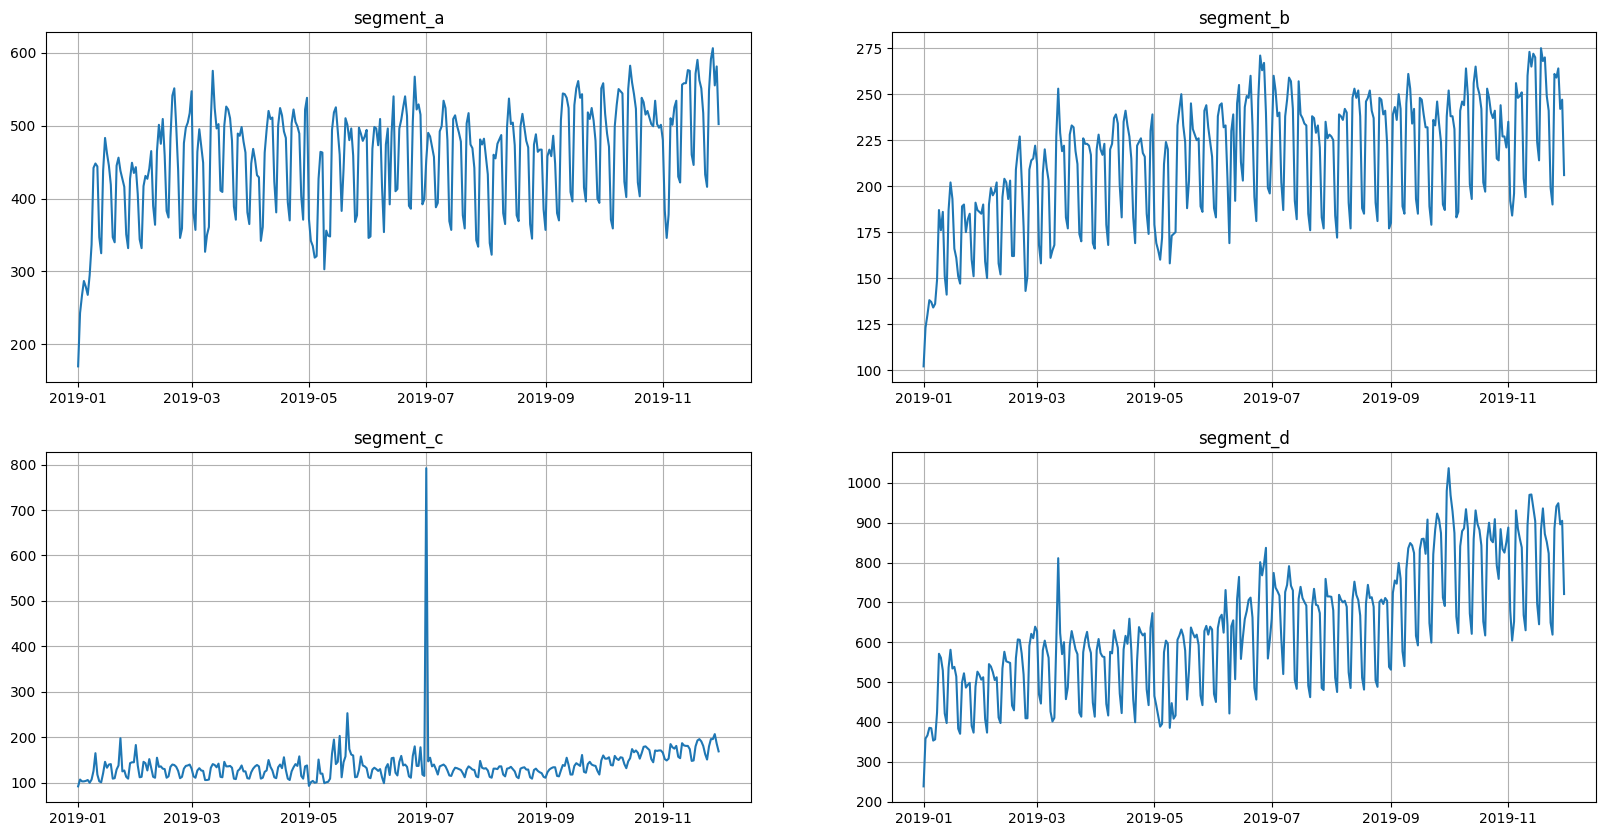

In [7]:
ts.plot()

Define transformations and model:

In [18]:
from etna.models import CatBoostMultiSegmentModel
from etna.transforms import DateFlagsTransform
from etna.transforms import DensityOutliersTransform
from etna.transforms import FourierTransform
from etna.transforms import LagTransform
from etna.transforms import LinearTrendTransform
from etna.transforms import MeanTransform
from etna.transforms import SegmentEncoderTransform
from etna.transforms import TimeSeriesImputerTransform
from etna.transforms import TrendTransform

# Prepare transforms
transforms = [
    DensityOutliersTransform(in_column="target", distance_coef=3.0),
    TimeSeriesImputerTransform(in_column="target", strategy="forward_fill"),
    LinearTrendTransform(in_column="target"),
    TrendTransform(in_column="target", out_column="trend"),
    LagTransform(in_column="target", lags=list(range(HORIZON, 122)), out_column="target_lag"),
    DateFlagsTransform(week_number_in_month=True, out_column="date_flag"),
    FourierTransform(period=360.25, order=6, out_column="fourier"),
    SegmentEncoderTransform(),
    MeanTransform(in_column=f"target_lag_{HORIZON}", window=12, seasonality=7),
    MeanTransform(in_column=f"target_lag_{HORIZON}", window=7),
]

# Prepare model
model = CatBoostMultiSegmentModel()

Fit `Pipeline` and make a prediction:

In [19]:
from etna.pipeline import Pipeline

# Create and fit the pipeline
pipeline = Pipeline(model=model, transforms=transforms, horizon=HORIZON)
pipeline.fit(train_ts)

# Make a forecast
forecast_ts = pipeline.forecast()

/usr/local/lib/python3.12/dist-packages/etna/transforms/decomposition/detrend.py:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result[self.in_column] = no_trend_timeseries
/usr/local/lib/python3.12/dist-packages/etna/transforms/decomposition/detrend.py:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result[self.in_column] = no_trend_timeseries
/usr/local/lib/python3.12/dist-packages/etna/transforms/decomposition/detrend.py:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice f

Let's plot the results:

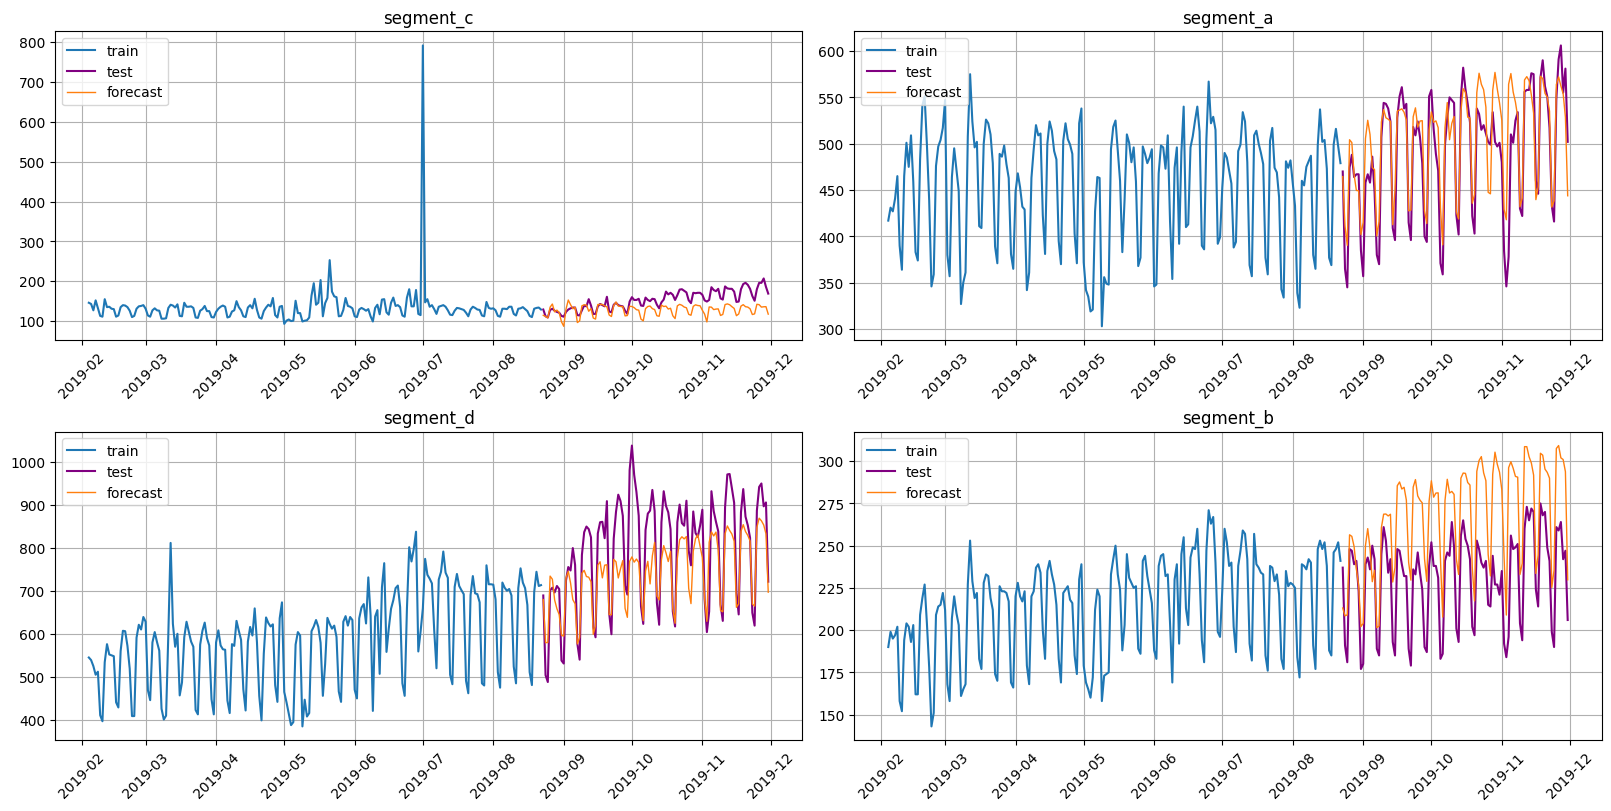

In [20]:
from etna.analysis import plot_forecast

plot_forecast(forecast_ts=forecast_ts, test_ts=test_ts, train_ts=train_ts, n_train_samples=200, figsize=(8,4))

Print the metric value across the segments:

In [ ]:
from etna.metrics import SMAPE

metric = SMAPE()
metric_value = metric(y_true=test_ts, y_pred=forecast_ts)
metric_value

{'segment_b': 3.271014290441896,
 'segment_d': 4.512871862697337,
 'segment_a': 4.799114474387907,
 'segment_c': 6.758606238307858}

In [21]:
pipeline = Pipeline(model=model, transforms=transforms, horizon=HORIZON)
pipeline.fit(ts)

# Make a forecast
forecast_ts_all = pipeline.forecast()

/usr/local/lib/python3.12/dist-packages/etna/transforms/decomposition/detrend.py:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result[self.in_column] = no_trend_timeseries
/usr/local/lib/python3.12/dist-packages/etna/transforms/decomposition/detrend.py:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result[self.in_column] = no_trend_timeseries
/usr/local/lib/python3.12/dist-packages/etna/transforms/decomposition/detrend.py:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice f

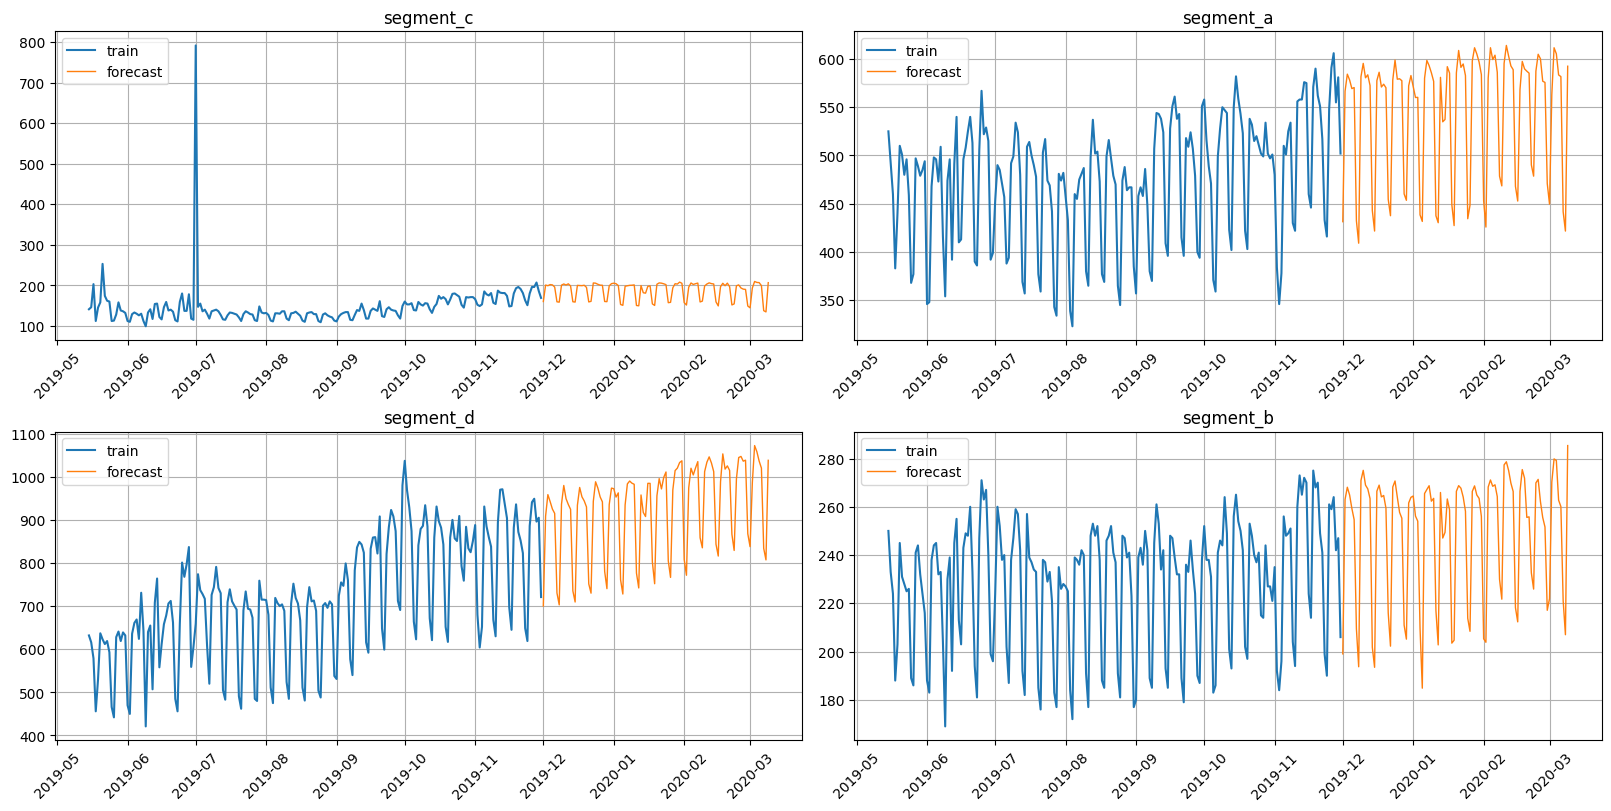

In [22]:
plot_forecast(
    forecast_ts=forecast_ts_all,
    train_ts=ts,
    n_train_samples=200,
    figsize=(8,4)
)

After this short introduction you can learn more about the library in our Tutorials section.

In [23]:
#
# Шаг 1. Генерация данных
#
import numpy as np
import pandas as pd
from etna.datasets import TSDataset
from etna.transforms import (
    LogTransform,
    LinearTrendTransform,
    FourierTransform,
    DateFlagsTransform,
    LagTransform,
    MeanTransform,
    # BinsregTrendTransform,
    TheilSenTrendTransform
)
from etna.models import CatBoostMultiSegmentModel
from etna.pipeline import Pipeline
from etna.analysis import plot_trend

# Параметры
np.random.seed(42)
n = 365 * 2  # 2 года ежедневных данных
dates = pd.date_range("2020-01-01", periods=n, freq="D")

# Тренд: экспоненциальный рост
trend = 100 * np.exp(0.002 * np.arange(n))

# Сезонность: недельная + годовая
season_weekly = 15 * np.sin(2 * np.pi * np.arange(n) / 7)
season_yearly = 25 * np.sin(2 * np.pi * np.arange(n) / 365.25)

# Шум
noise = np.random.normal(0, 4, n)

# Целевая переменная
y = trend + season_weekly + season_yearly + noise

# Формат для ETNA: требуется колонка "segment"
df = pd.DataFrame({
    "timestamp": dates,
    "segment": "product_A",  # можно добавить несколько сегментов
    "target": y
})

# Создаём TSDataset
ts = TSDataset(df=TSDataset.to_dataset(df), freq="D")

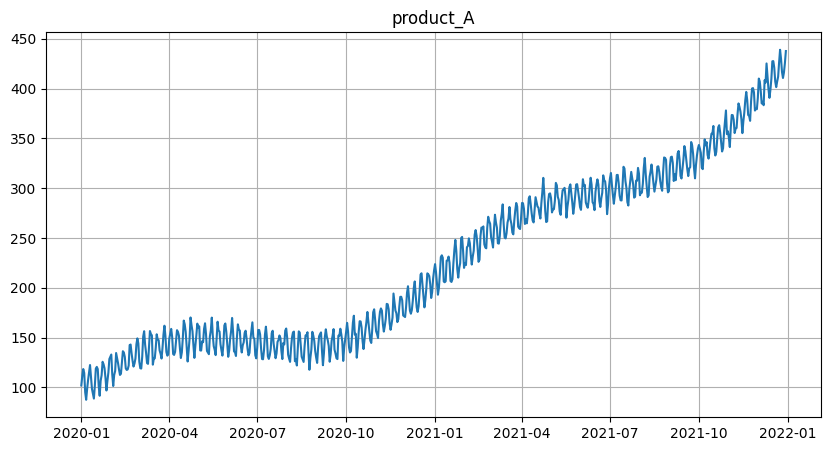

In [24]:
ts.plot()

In [25]:
# Create and fit the pipeline
pipeline = Pipeline(model=model, transforms=transforms, horizon=HORIZON)
pipeline.fit(ts)

# Make a forecast
forecast_ts_exp = pipeline.forecast()

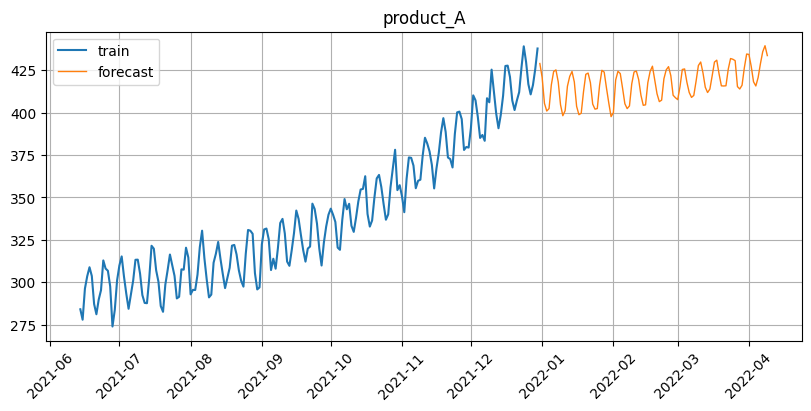

In [26]:
plot_forecast(
    forecast_ts=forecast_ts_exp,
    train_ts=ts,
    n_train_samples=200,
    figsize=(8,4)
)